In [1]:
from zipfile import ZipFile
file_name='/content/MIt-BIH Datasets.zip'
with ZipFile(file_name,'r') as zipp:
  zipp.extractall()

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from keras.utils.np_utils import to_categorical
from sklearn.utils import class_weight
import warnings

from keras.preprocessing.sequence import TimeseriesGenerator

from keras.models import Sequential
from keras.layers import Reshape
from keras.models import Model

from keras.layers import Dense, Activation, Flatten, Convolution1D, Dropout,MaxPooling1D , Input
from tensorflow.keras.optimizers import Adam 
from keras.callbacks import LearningRateScheduler

import itertools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, label_ranking_average_precision_score, label_ranking_loss, coverage_error 

from tensorflow.keras.layers import BatchNormalization
import pandas
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.wrappers.scikit_learn import KerasClassifier
from keras.layers import Dropout, Flatten, Dense 
from keras.utils import np_utils
from keras import optimizers
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from numpy import mean
from numpy import std
from tensorflow.keras.optimizers import Adam , Adadelta
from sklearn.ensemble import StackingClassifier

import tensorflow as tf
from tensorflow.keras.layers import Flatten, Dense, Conv1D, MaxPool1D, Dropout

warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
train = pd.read_csv("/content/MIt-BIH Datasets/train.csv" , header = None)
validate = pd.read_csv("/content/MIt-BIH Datasets/validate.csv", header = None)
test = pd.read_csv("/content/MIt-BIH Datasets/test.csv" , header = None)


In [4]:
combine = [train , validate]

In [5]:
train = pd.concat(combine , axis = 0 )

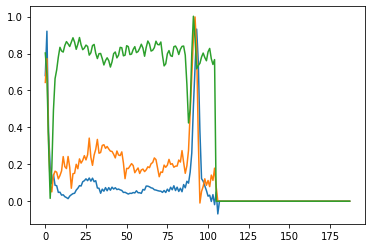

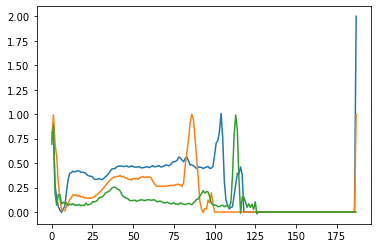

In [6]:
for i in range(3): plt.plot(train.iloc[i])
plt.show()
for i in range(3): plt.plot(test.iloc[i])
plt.show()

In [7]:
train.rename(columns={187:"Class"}, inplace=True)
test.rename(columns={187:"Class"}, inplace=True)


In [8]:
train['Class'].unique()

array([ 0., 15.,  8., 17.,  2.,  1.,  4., 12.,  5., 14., 10.,  6., 18.])

In [9]:
mapping = {    
               0 : 'Normal Beat',
               1 : 'Left bundle branch block beat',
               2 : 'Right bundle branch block beat',
               4 : 'Atrial premature beat',
               5 : 'Aberrated atrial premature beat',
               6 : 'Nodal (junctional) premature beat',
             
               8 : 'Premature ventricular contraction',
               10 : 'Fusion of ventricular and normal beat',
             
               12 : 'Nodal (junctional) escape beat',
               14 : 'Ventricular escape beat',
               15 : 'Paced beat',
             
               17 : 'Unclassifiable beat',
                18: 'Fusion of paced and normal beat'

               }

In [10]:
train['label'] = train.iloc[:, -1].map(mapping)
test['label'] = test.iloc[:, -1].map(mapping)


In [11]:
# Applying Smote
df_15=train[train['Class']==15]
df_2=train[train['Class']==2]
df_1=train[train['Class']==1]
df_8=train[train['Class']==8]
df_4=train[train['Class']==4]

df_10=train[train['Class']==10]
df_12=train[train['Class']==12]
df_6=train[train['Class']==6]
df_14=train[train['Class']==14]
df_5=train[train['Class']==5]
df_17=train[train['Class']==17]
df_18= train[train['Class']==18]



df_0=(train[train['Class']==0]).sample(n=20000,random_state=42)


train=pd.concat([df_0,df_15,df_2,df_1,df_8,df_4,df_10,df_12,df_6,df_14,df_5,df_17,df_18])

In [12]:
X_train=train.iloc[:,:186].values
X_test=test.iloc[:,:186].values


In [13]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=1)
X_train, y_train = oversample.fit_resample(X_train, train["Class"])


In [14]:
from collections import Counter

counter = Counter(y_train)
print(counter)

Counter({0.0: 20000, 15.0: 20000, 2.0: 20000, 1.0: 20000, 8.0: 20000, 4.0: 20000, 10.0: 20000, 12.0: 20000, 6.0: 20000, 14.0: 20000, 5.0: 20000, 17.0: 20000, 18.0: 20000})


In [15]:
X_train = X_train.reshape(len(X_train), X_train.shape[1],1)
X_test = X_test.reshape(len(X_test), X_test.shape[1],1)


In [16]:
target_test=test["Class"]
y_test = target_test

In [17]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [18]:
X_train.shape

(260000, 186, 1)

In [19]:
pip install attention

     |████████████████████████████████| 462 kB 5.2 MB/s 


In [20]:

from tensorflow.keras.optimizers import SGD
NUM_EPOCHS = 25
INIT_LR = 1e-2
BS = 500
opt = SGD(lr=INIT_LR, momentum=0.9, decay=INIT_LR / NUM_EPOCHS)


In [21]:
!pip install scikeras
from scikeras.wrappers import KerasClassifier

In [22]:
# attention model
from tensorflow.keras.layers import Conv1D, Input, LSTM, Activation, Dense, Average
from tensorflow.keras import regularizers
from keras.layers import BatchNormalization

from attention import Attention


inputs_1 = Input(shape = (186,1))

def Attention_Network(neurons=200):
  

  x = LSTM(64, return_sequences = True)(inputs_1)


  x = Attention(units=32)(x)

  x = Conv1D(128 ,5)(inputs_1)
  x = Activation('relu')(x)

  x = Conv1D(64 ,5 )(x)
  x = Activation('relu')(x)


  x = Conv1D(32 ,5 )(x)
  x = Activation('relu')(x)

  x=Flatten()(x)


  x = Dense(256)(x)
  x = BatchNormalization()(x)
  x = Activation('relu')(x)
  x = Dense(127)(x)
  x= BatchNormalization()(x)
  x = Activation('relu')(x)
  outputs = Dense(13, activation = 'softmax')(x)
  model = tf.keras.models.Model(inputs = inputs_1, outputs = outputs)
  
  
  
  
  model.compile(optimizer='adam' , loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  return model


attention_clf = KerasClassifier(build_fn=Attention_Network, epochs=10, batch_size=500, verbose=1)
attention_clf._estimator_type = "classifier"


In [23]:
n_obs, feature, depth = X_train.shape
batch_size = 500

In [24]:

# model Residual

from keras.layers import Input, Dense, Conv1D, MaxPooling1D, Softmax, Add, Flatten, Activation# , Dropout

def Residual_Network(neurons = 200):
  inp = Input(shape=(feature, depth))
  C = Conv1D(filters=32, kernel_size=5, strides=1)(inp)
  C11 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(C)
  A11 = Activation("relu")(C11)

  C12 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A11)
  S11 = Add()([C12, C])
  A12 = Activation("relu")(S11)
  M11 = MaxPooling1D(pool_size=5, strides=2)(A12)


  C21 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M11)
  A21 = Activation("relu")(C21)
  C22 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A21)
  S21 = Add()([C22, M11])
  A22 = Activation("relu")(S11)
  M21 = MaxPooling1D(pool_size=5, strides=2)(A22)


  C31 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M21)
  A31 = Activation("relu")(C31)
  C32 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A31)
  S31 = Add()([C32, M21])
  A32 = Activation("relu")(S31)
  M31 = MaxPooling1D(pool_size=5, strides=2)(A32)


  C41 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M31)
  A41 = Activation("relu")(C41)
  C42 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A41)
  S41 = Add()([C42, M31])
  A42 = Activation("relu")(S41)
  M41 = MaxPooling1D(pool_size=5, strides=2)(A42)


  C51 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M41)
  A51 = Activation("relu")(C51)
  C52 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A51)
  S51 = Add()([C52, M41])
  A52 = Activation("relu")(S51)
  M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

  F1 = Flatten()(M51)

  D1 = Dense(32)(F1)
  A6 = Activation("relu")(D1)
  D2 = Dense(32)(A6)
  D3 = Dense(13)(D2)
  A7 = Softmax()(D3)

  model = Model(inputs=inp, outputs=A7)
  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  return model


Residual_clf = KerasClassifier(build_fn=Residual_Network, epochs=10, batch_size=500, verbose=1)
Residual_clf._estimator_type = "classifier"



In [25]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from collections import defaultdict

In [26]:
models_dict = {
      'Attantion':attention_clf,
      'Residual': Residual_clf
               
               }

In [27]:
def evaluate_model(model, X, y):
    cv = StratifiedKFold(n_splits=3)
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, verbose=1,  error_score='raise')
    return scores

In [28]:
model_scores = defaultdict()

In [29]:
for name, model in models_dict.items():
    print('Evaluating {}'.format(name))
    scores = evaluate_model(model, X_train, y_train)
    model_scores[name] = scores

Evaluating Attantion


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Epoch 1/10
416/416 [==============================] - 34s 46ms/step - loss: 0.1736 - accuracy: 0.9520
Epoch 2/10
416/416 [==============================] - 18s 43ms/step - loss: 0.0311 - accuracy: 0.9909
Epoch 3/10
416/416 [==============================] - 18s 43ms/step - loss: 0.0170 - accuracy: 0.9948
Epoch 4/10
416/416 [==============================] - 18s 44ms/step - loss: 0.0096 - accuracy: 0.9970
Epoch 5/10
416/416 [==============================] - 18s 43ms/step - loss: 0.0082 - accuracy: 0.9976
Epoch 6/10
416/416 [==============================] - 19s 45ms/step - loss: 0.0063 - accuracy: 0.9981
Epoch 7/10
416/416 [==============================] - 18s 43ms/step - loss: 0.0059 - accuracy: 0.9983
Epoch 8/10
416/416 [==============================] - 18s 43ms/step - loss: 0.0055 - accuracy: 0.9985
Epoch 9/10
416/416 [==============================] - 18s 43ms/step - loss: 0.0052 - accuracy: 0.9984
Epoch 10/10
104/104 [==============================] - 2s 16ms/step
Epoch 1/10
416

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 16.2min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Evaluating Residual
Epoch 1/10
416/416 [==============================] - 16s 34ms/step - loss: 0.6122 - accuracy: 0.7991
Epoch 2/10
416/416 [==============================] - 14s 33ms/step - loss: 0.1794 - accuracy: 0.9448
Epoch 3/10
416/416 [==============================] - 14s 33ms/step - loss: 0.1182 - accuracy: 0.9637
Epoch 4/10
416/416 [==============================] - 14s 34ms/step - loss: 0.0890 - accuracy: 0.9723
Epoch 5/10
416/416 [==============================] - 14s 34ms/step - loss: 0.0702 - accuracy: 0.9779
Epoch 6/10
416/416 [==============================] - 14s 34ms/step - loss: 0.0587 - accuracy: 0.9813
Epoch 7/10
416/416 [==============================] - 14s 33ms/step - loss: 0.0496 - accuracy: 0.9842
Epoch 8/10
416/416 [==============================] - 14s 33ms/step - loss: 0.0441 - accuracy: 0.9863
Epoch 9/10
416/416 [==============================] - 14s 33ms/step - loss: 0.0384 - accuracy: 0.9880
Epoch 10/10
104/104 [==============================] - 1s 10ms

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 12.0min finished


In [30]:
pip install datapane


     |████████████████████████████████| 2.6 MB 5.1 MB/s 
     |████████████████████████████████| 45 kB 3.8 MB/s 
     |████████████████████████████████| 97 kB 7.7 MB/s 
     |████████████████████████████████| 54 kB 2.9 MB/s 
     |████████████████████████████████| 46 kB 3.7 MB/s 
     |████████████████████████████████| 11.1 MB 34.0 MB/s 
     |████████████████████████████████| 596 kB 40.4 MB/s 
     |████████████████████████████████| 193 kB 34.6 MB/s 
     |████████████████████████████████| 46 kB 2.0 MB/s 
  Created wheel for face: filename=face-20.1.1-py3-none-any.whl size=51091 sha256=ab3e7be4b2d9086930eb396c9b7c0622cafe07f1a7ad1e3563d5078b09e0e69c
  Stored in directory: /root/.cache/pip/wheels/67/03/c2/76d2e1e694852ce409ac2938b9f461bc0fdf3789901e7bb1f0
  Created wheel for micawber: filename=micawber-0.5.4-py3-none-any.whl size=22373 sha256=31658f87eaf341870859878980457860b90c945bc62834bec4a58010857e8cdb
  Stored in directory: /root/.cache/pip/wheels/c1/b6/81/f8237c6061ac239fe1079fa3

In [31]:
import plotly.graph_objects as go
import datapane as dp

In [32]:
def plot_results(model_scores, name):
    
    model_names = list(model_scores.keys())
    results = [model_scores[model] for model in model_names]
    fig = go.Figure()
    for model, result in zip(model_names, results):
        fig.add_trace(go.Box(
            y=result,
            name=model,
            boxpoints='all',
            jitter=0.5,
            whiskerwidth=0.2,
            marker_size=2,
            line_width=1)
        )
    
    fig.update_layout(
    title='Performance of Different Models Using 5-Fold Cross-Validation',
    paper_bgcolor='rgb(243, 243, 243)',
    plot_bgcolor='rgb(243, 243, 243)',
    xaxis_title='Model',
    yaxis_title='Accuracy',
    showlegend=False)
    fig.show()
    
    report = dp.Report(dp.Plot(fig) ) #Create a report
    #report.publish(name=name, open=True, visibility='PUBLIC') 

plot_results(model_scores, name='base_models_cv')

Bokeh version 2.3.3 is not supported, these plots may not display correctly, please install version ~=2.2.0
Folium version 0.8.3 is not supported, these plots may not display correctly, please install version >=0.12.0


In [41]:
base_models = [('attention', attention_clf),
               ('noResidual', Residual_clf)]

In [42]:
#cv = 5
n_estimator =5
stacking_classifier_attention = StackingClassifier(estimators=base_models, 
                                    passthrough=True, 
                                    cv=3,
                                    verbose=2)


In [43]:
X_train = X_train.reshape(260000,186)

In [44]:
stacking_scores_attention = evaluate_model(stacking_classifier_attention, X_train, y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Epoch 1/10
416/416 [==============================] - 20s 46ms/step - loss: 0.1674 - accuracy: 0.9525
Epoch 2/10
416/416 [==============================] - 19s 45ms/step - loss: 0.0294 - accuracy: 0.9912
Epoch 3/10
416/416 [==============================] - 18s 43ms/step - loss: 0.0149 - accuracy: 0.9955
Epoch 4/10
416/416 [==============================] - 18s 43ms/step - loss: 0.0097 - accuracy: 0.9971
Epoch 5/10
416/416 [==============================] - 18s 44ms/step - loss: 0.0080 - accuracy: 0.9976
Epoch 6/10
416/416 [==============================] - 18s 44ms/step - loss: 0.0074 - accuracy: 0.9977
Epoch 7/10
416/416 [==============================] - 21s 51ms/step - loss: 0.0052 - accuracy: 0.9984
Epoch 8/10
416/416 [==============================] - 19s 45ms/step - loss: 0.0050 - accuracy: 0.9985
Epoch 9/10
416/416 [==============================] - 19s 46ms/step - loss: 0.0054 - accuracy: 0.9985
Epoch 10/10
416/416 [==============================] - 18s 43ms/step - loss: 0.003

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Epoch 1/10
278/278 [==============================] - 14s 44ms/step - loss: 0.2297 - accuracy: 0.9350
Epoch 2/10
278/278 [==============================] - 12s 44ms/step - loss: 0.0404 - accuracy: 0.9885
Epoch 3/10
278/278 [==============================] - 12s 43ms/step - loss: 0.0221 - accuracy: 0.9935
Epoch 4/10
278/278 [==============================] - 12s 42ms/step - loss: 0.0150 - accuracy: 0.9956
Epoch 5/10
278/278 [==============================] - 12s 42ms/step - loss: 0.0097 - accuracy: 0.9971
Epoch 6/10
278/278 [==============================] - 12s 42ms/step - loss: 0.0064 - accuracy: 0.9981
Epoch 7/10
278/278 [==============================] - 12s 43ms/step - loss: 0.0061 - accuracy: 0.9982
Epoch 8/10
278/278 [==============================] - 12s 43ms/step - loss: 0.0082 - accuracy: 0.9977
Epoch 9/10
278/278 [==============================] - 12s 43ms/step - loss: 0.0055 - accuracy: 0.9984
Epoch 10/10
139/139 [==============================] - 2s 15ms/step


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.1min remaining:    0.0s


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.7min remaining:    0.0s


Epoch 1/10
278/278 [==============================] - 11s 34ms/step - loss: 0.7928 - accuracy: 0.7378
Epoch 2/10
278/278 [==============================] - 10s 34ms/step - loss: 0.2470 - accuracy: 0.9235
Epoch 3/10
278/278 [==============================] - 10s 34ms/step - loss: 0.1601 - accuracy: 0.9498
Epoch 4/10
278/278 [==============================] - 10s 34ms/step - loss: 0.1159 - accuracy: 0.9636
Epoch 5/10
278/278 [==============================] - 10s 34ms/step - loss: 0.1000 - accuracy: 0.9683
Epoch 6/10
278/278 [==============================] - 10s 34ms/step - loss: 0.0830 - accuracy: 0.9735
Epoch 7/10
278/278 [==============================] - 10s 35ms/step - loss: 0.0749 - accuracy: 0.9755
Epoch 8/10
278/278 [==============================] - 10s 34ms/step - loss: 0.0632 - accuracy: 0.9793
Epoch 9/10
278/278 [==============================] - 10s 35ms/step - loss: 0.0573 - accuracy: 0.9815
Epoch 10/10
139/139 [==============================] - 2s 11ms/step
Epoch 1/10
278

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  5.8min finished


104/104 [==============================] - 1s 11ms/step


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 102.2min finished


In [45]:
model_scores['stacking_Attention'] = stacking_scores_attention


In [46]:
plot_results(model_scores, name='stacking_model_cv')

In [47]:
# evaluate bagging ensemble for regression
from numpy import mean
from numpy import std

for model in model_scores:
     print(model, '->', model_scores[model]  , 'MAE: %.3f (%.3f)' % (mean(model_scores[model]), std(model_scores[model])))


Attantion -> [0.98371154 0.99446154 0.99438462 0.99394231 0.99163462] MAE: 0.992 (0.004)
Residual -> [0.98411538 0.98651923 0.98792308 0.98569231 0.98875   ] MAE: 0.987 (0.002)
stacking_Attention -> [0.99382692 0.99540385 0.99684615 0.99646154 0.99521154] MAE: 0.996 (0.001)


In [48]:
stacking_model_attention = stacking_classifier_attention.fit(X_train,y_train)

Epoch 1/10
520/520 [==============================] - 28s 49ms/step - loss: 0.1387 - accuracy: 0.9606
Epoch 2/10
520/520 [==============================] - 24s 46ms/step - loss: 0.0251 - accuracy: 0.9924
Epoch 3/10
520/520 [==============================] - 24s 45ms/step - loss: 0.0134 - accuracy: 0.9960
Epoch 4/10
520/520 [==============================] - 25s 48ms/step - loss: 0.0088 - accuracy: 0.9974
Epoch 5/10
520/520 [==============================] - 25s 48ms/step - loss: 0.0073 - accuracy: 0.9978
Epoch 6/10
520/520 [==============================] - 24s 47ms/step - loss: 0.0057 - accuracy: 0.9983
Epoch 7/10
520/520 [==============================] - 24s 47ms/step - loss: 0.0046 - accuracy: 0.9987
Epoch 8/10
520/520 [==============================] - 24s 47ms/step - loss: 0.0058 - accuracy: 0.9982
Epoch 9/10
520/520 [==============================] - 24s 47ms/step - loss: 0.0038 - accuracy: 0.9989
Epoch 10/10
520/520 [==============================] - 24s 46ms/step - loss: 0.004

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Epoch 1/10
347/347 [==============================] - 17s 47ms/step - loss: 0.2006 - accuracy: 0.9438
Epoch 2/10
347/347 [==============================] - 15s 45ms/step - loss: 0.0337 - accuracy: 0.9902
Epoch 3/10
347/347 [==============================] - 16s 46ms/step - loss: 0.0179 - accuracy: 0.9950
Epoch 4/10
347/347 [==============================] - 16s 46ms/step - loss: 0.0111 - accuracy: 0.9968
Epoch 5/10
347/347 [==============================] - 16s 45ms/step - loss: 0.0082 - accuracy: 0.9978
Epoch 6/10
347/347 [==============================] - 16s 46ms/step - loss: 0.0095 - accuracy: 0.9973
Epoch 7/10
347/347 [==============================] - 15s 44ms/step - loss: 0.0059 - accuracy: 0.9983
Epoch 8/10
347/347 [==============================] - 16s 47ms/step - loss: 0.0046 - accuracy: 0.9988
Epoch 9/10
347/347 [==============================] - 15s 44ms/step - loss: 0.0070 - accuracy: 0.9979
Epoch 10/10
174/174 [==============================] - 3s 16ms/step


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  3.5min remaining:    0.0s


Epoch 1/10
347/347 [==============================] - 17s 44ms/step - loss: 0.1891 - accuracy: 0.9467
Epoch 2/10
347/347 [==============================] - 16s 47ms/step - loss: 0.0409 - accuracy: 0.9880
Epoch 3/10
347/347 [==============================] - 16s 45ms/step - loss: 0.0221 - accuracy: 0.9935
Epoch 4/10
347/347 [==============================] - 16s 46ms/step - loss: 0.0150 - accuracy: 0.9955
Epoch 5/10
347/347 [==============================] - 16s 45ms/step - loss: 0.0109 - accuracy: 0.9967
Epoch 6/10
347/347 [==============================] - 16s 45ms/step - loss: 0.0079 - accuracy: 0.9977
Epoch 7/10
347/347 [==============================] - 16s 47ms/step - loss: 0.0080 - accuracy: 0.9976
Epoch 8/10
347/347 [==============================] - 15s 44ms/step - loss: 0.0060 - accuracy: 0.9984
Epoch 9/10
347/347 [==============================] - 16s 47ms/step - loss: 0.0074 - accuracy: 0.9977
Epoch 10/10
174/174 [==============================] - 3s 15ms/step
Epoch 1/10
347

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  9.0min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Epoch 1/10
347/347 [==============================] - 14s 35ms/step - loss: 0.6225 - accuracy: 0.7989
Epoch 2/10
347/347 [==============================] - 12s 34ms/step - loss: 0.1659 - accuracy: 0.9495
Epoch 3/10
347/347 [==============================] - 12s 34ms/step - loss: 0.1118 - accuracy: 0.9657
Epoch 4/10
347/347 [==============================] - 12s 34ms/step - loss: 0.0800 - accuracy: 0.9749
Epoch 5/10
347/347 [==============================] - 12s 34ms/step - loss: 0.0674 - accuracy: 0.9787
Epoch 6/10
347/347 [==============================] - 12s 34ms/step - loss: 0.0593 - accuracy: 0.9814
Epoch 7/10
347/347 [==============================] - 12s 34ms/step - loss: 0.0526 - accuracy: 0.9831
Epoch 8/10
347/347 [==============================] - 12s 34ms/step - loss: 0.0462 - accuracy: 0.9851
Epoch 9/10
347/347 [==============================] - 12s 34ms/step - loss: 0.0421 - accuracy: 0.9867
Epoch 10/10
174/174 [==============================] - 2s 10ms/step


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.1min remaining:    0.0s


Epoch 1/10
347/347 [==============================] - 13s 34ms/step - loss: 0.6948 - accuracy: 0.7730
Epoch 2/10
347/347 [==============================] - 12s 34ms/step - loss: 0.2019 - accuracy: 0.9379
Epoch 3/10
347/347 [==============================] - 12s 34ms/step - loss: 0.1343 - accuracy: 0.9583
Epoch 4/10
347/347 [==============================] - 12s 34ms/step - loss: 0.1000 - accuracy: 0.9687
Epoch 5/10
347/347 [==============================] - 12s 34ms/step - loss: 0.0824 - accuracy: 0.9741
Epoch 6/10
347/347 [==============================] - 12s 34ms/step - loss: 0.0688 - accuracy: 0.9784
Epoch 7/10
347/347 [==============================] - 12s 34ms/step - loss: 0.0627 - accuracy: 0.9798
Epoch 8/10
347/347 [==============================] - 12s 34ms/step - loss: 0.0521 - accuracy: 0.9832
Epoch 9/10
347/347 [==============================] - 12s 34ms/step - loss: 0.0459 - accuracy: 0.9852
Epoch 10/10
174/174 [==============================] - 2s 11ms/step
Epoch 1/10
347

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  7.0min finished


In [50]:
X_test.shape

(29865, 186, 1)

In [53]:
X_test = X_test.reshape(29865,186)

In [54]:
y_pred_attention = stacking_model_attention.predict(X_test)

60/60 [==============================] - 1s 13ms/step


In [55]:
print("Stacking Accuracy With Lstm is : " , accuracy_score(y_test, y_pred_attention) )


Stacking Accuracy With Lstm is :  0.9738824711200402


In [56]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')



Confusion matrix, without normalization


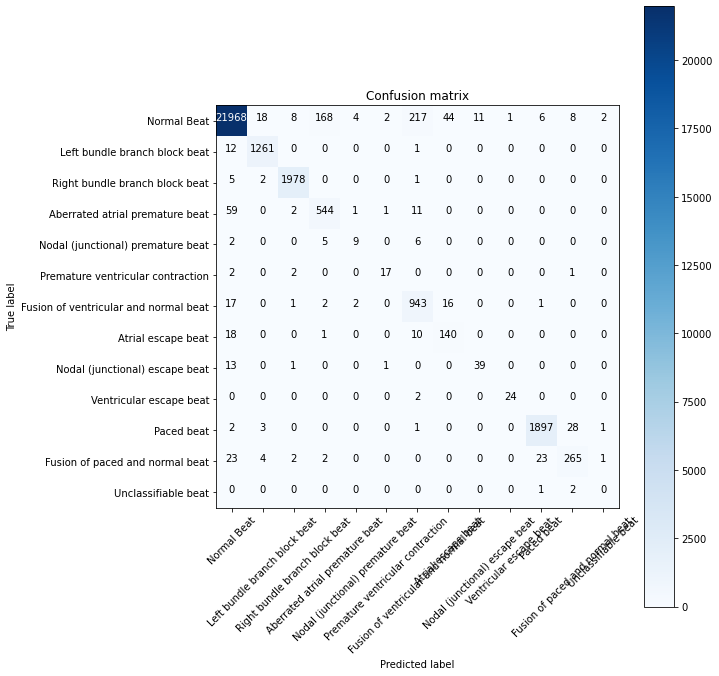

In [57]:
# Compute confusion matrix
cnf_matrix_attention = confusion_matrix(y_test, y_pred_attention)

# Plot non-normalized confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(cnf_matrix_attention, classes=['Normal Beat',
                'Left bundle branch block beat',
                'Right bundle branch block beat',
              
                'Aberrated atrial premature beat',
                'Nodal (junctional) premature beat',
          
                'Premature ventricular contraction',
                'Fusion of ventricular and normal beat',
                'Atrial escape beat',
                'Nodal (junctional) escape beat',
                'Ventricular escape beat',
                'Paced beat',
                'Fusion of paced and normal beat',
                'Unclassifiable beat'],
                      title='Confusion matrix')
plt.show()

In [58]:
from sklearn import metrics
fpr_attention, tpr_attention, thresholds_attention = metrics.roc_curve(y_test, y_pred_attention, pos_label=2)

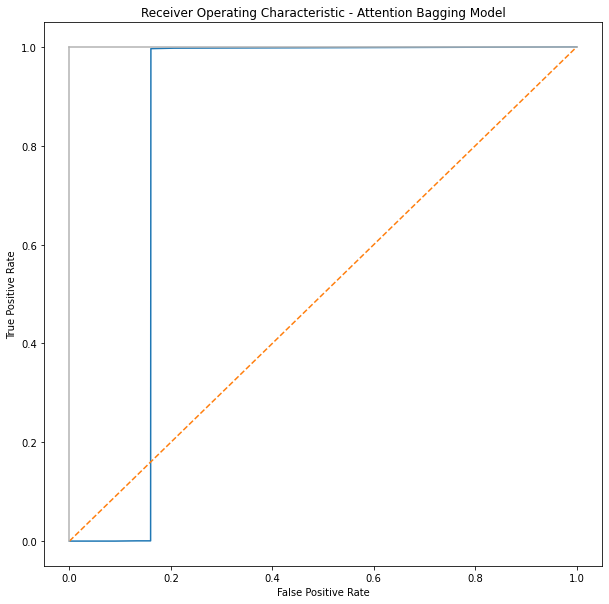

In [59]:
plt.subplots(1, figsize=(10,10))
plt.title('Receiver Operating Characteristic - Attention Bagging Model')
plt.plot(fpr_attention, tpr_attention)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [60]:
from sklearn import metrics
auc_attention = metrics.auc(fpr_attention, tpr_attention)
print("Attention Auc is : ")
print(auc_attention )

Attention Auc is : 
0.8385857735017824
